In [25]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from datasets import Dataset

In [3]:
df = pd.read_csv('bersatu_finetune.csv')

# pilih kolom
df = df[['clean_textdisplay', 'label']].copy()

# hapus data kosong
df = df.dropna()

# rapihin label
df['label'] = (
    df['label']
    .astype(str)
    .str.lower()
    .str.strip()
)


In [4]:
# mapping label indonesia
label_mapping = {
    'negatif': 0,
    'netral': 1,
    'positif': 2
}

df['label'] = df['label'].map(label_mapping)

# cek hasil
print(df['label'].value_counts())
print(df.head())

label
1    800
0    800
2    800
Name: count, dtype: int64
                                   clean_textdisplay  label
0  ada ga ada mobil listrik pabrikan nikel terus ...      1
1  akhirnya persaingan negara china dengan electr...      1
2  baterai electric vehicle di recycle menjadi bl...      1
3  bcara baterai mobil bensin solar pun ada bater...      1
4  betul dokter mobil yg ceritakan ku pake mobil ...      1


In [5]:
df = df.dropna(subset=['label'])

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

# Convert to HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [6]:
MODEL_NAME = "indolem/indobertweet-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [7]:
def tokenize_function(example):
    return tokenizer(
        example['clean_textdisplay'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/1920 [00:00<?, ? examples/s]

Map:   0%|          | 0/480 [00:00<?, ? examples/s]

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc
    }

In [10]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    warmup_ratio=0.1,
    weight_decay=0.01,
    label_smoothing_factor=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_dir="./logs",
    logging_steps=10
)

In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [12]:
trainer.train()

/Users/mthariqsultand/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.964600,0.874504,0.656250
2,0.788900,0.818732,0.683333
3,0.638700,0.824316,0.706250


/Users/mthariqsultand/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/mthariqsultand/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=360, training_loss=0.7863219300905864, metrics={'train_runtime': 190.8917, 'train_samples_per_second': 30.174, 'train_steps_per_second': 1.886, 'total_flos': 378883321528320.0, 'train_loss': 0.7863219300905864, 'epoch': 3.0})

In [14]:
model.save_pretrained("./indobertweet-finetuned")
tokenizer.save_pretrained("./indobertweet-finetuned")

('./indobertweet-finetuned/tokenizer_config.json',
 './indobertweet-finetuned/special_tokens_map.json',
 './indobertweet-finetuned/vocab.txt',
 './indobertweet-finetuned/added_tokens.json',
 './indobertweet-finetuned/tokenizer.json')

/Users/mthariqsultand/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Accuracy:
0.6833333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.66      0.66       160
           1       0.64      0.77      0.70       160
           2       0.78      0.62      0.69       160

    accuracy                           0.68       480
   macro avg       0.69      0.68      0.68       480
weighted avg       0.69      0.68      0.68       480


Confusion Matrix:
[[105  41  14]
 [ 22 123  15]
 [ 33  27 100]]


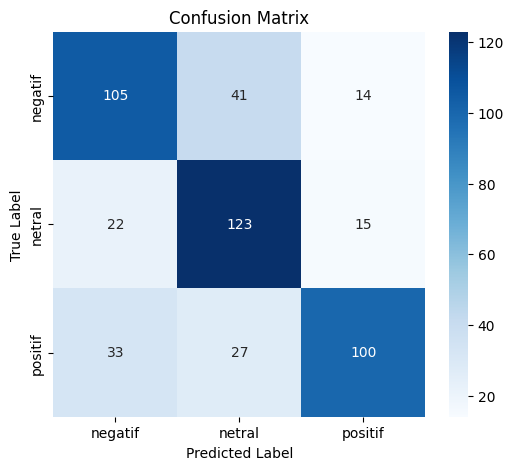

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print("\nAccuracy:")
print(accuracy_score(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Visualisasi confusion matrix
labels = ['negatif', 'netral', 'positif']
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()